# Deepfake Detector Benchmark

Companion notebook to the research proposal **"Investigating the Impact of Deepfake Technology on Digital Media Trust and the Role of Detection Tools"** (Madhurima Mani, University of West London).

This notebook implements the proposal's **Detection Benchmarking Methodology**: comparing pretrained deepfake detectors on accuracy, false positive rate (FPR), and inference latency, following the same evaluation axes as the DFDC benchmark (Dolhansky et al., 2020).

**Run this top to bottom.** No setup needed beyond the install cell below — Colab gives you free CPU/GPU and full internet access.


## 1. Install dependencies

In [22]:
!pip install -q transformers datasets torch pillow scikit-learn matplotlib


## 2. Config

Three pretrained deepfake detectors (all public on Hugging Face) and a labeled real/fake face dataset.

In [23]:
import csv
import time
from dataclasses import dataclass, field

from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import confusion_matrix, accuracy_score

MODELS = [
    "dima806/deepfake_vs_real_image_detection",
    "prithivMLmods/Deep-Fake-Detector-v2-Model",
    "prithivMLmods/Deepfake-Detect-Siglip2",
]

DATASET_NAME = "Hemg/deepfake-and-real-images"
DATASET_SPLIT = "test"
SAMPLE_SIZE = 200  # raise this once the pipeline works end-to-end


## 3. Load the sample

This prints the dataset's actual feature/label names first — deepfake datasets don't use a
consistent 0/1 convention across sources, so check this output before trusting the results.

In [24]:
def load_sample():
    try:
        ds = load_dataset(DATASET_NAME, split=DATASET_SPLIT)
    except (ValueError, KeyError):
        ds = load_dataset(DATASET_NAME, split="train")

    print("Dataset features:", ds.features)
    label_names = getattr(ds.features.get("label"), "names", None)
    print("Label names:", label_names)
    fake_index = [n.lower() for n in label_names].index("fake") if label_names and "fake" in [n.lower() for n in label_names] else 1

    ds = ds.shuffle(seed=42).select(range(min(SAMPLE_SIZE, len(ds))))
    return [(row["image"], row["label"] == fake_index) for row in ds]

samples = load_sample()
print(f"Loaded {len(samples)} samples")

Dataset features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['Fake', 'Real'])}
Label names: ['Fake', 'Real']
Loaded 200 samples


## 4. Benchmark each model

Computes accuracy, false positive rate, and average inference latency per model.

In [25]:
@dataclass
class ModelResult:
    model_name: str
    accuracy: float = 0.0
    false_positive_rate: float = 0.0
    avg_latency_ms: float = 0.0
    n_samples: int = 0
    confusion: list = field(default_factory=list)


def label_is_fake(pred_label: str) -> bool:
    fake_terms = {"fake", "deepfake", "ai", "synthetic", "generated"}
    return any(term in pred_label.lower() for term in fake_terms)


def benchmark_model(model_name: str, samples) -> ModelResult:
    clf = pipeline("image-classification", model=model_name)

    y_true, y_pred, latencies = [], [], []
    for image, is_fake in samples:
        start = time.perf_counter()
        top_pred = clf(image)[0]
        latencies.append((time.perf_counter() - start) * 1000)

        y_true.append(int(is_fake))
        y_pred.append(int(label_is_fake(top_pred["label"])))

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0

    return ModelResult(
        model_name=model_name,
        accuracy=accuracy_score(y_true, y_pred),
        false_positive_rate=fpr,
        avg_latency_ms=sum(latencies) / len(latencies),
        n_samples=len(samples),
        confusion=[[int(tn), int(fp)], [int(fn), int(tp)]],
    )

results = [benchmark_model(m, samples) for m in MODELS]
for r in results:
    print(f"{r.model_name:45s} acc={r.accuracy:.3f}  FPR={r.false_positive_rate:.3f}  latency={r.avg_latency_ms:.1f}ms")


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

dima806/deepfake_vs_real_image_detection      acc=0.990  FPR=0.010  latency=826.0ms
prithivMLmods/Deep-Fake-Detector-v2-Model     acc=0.100  FPR=0.959  latency=696.2ms
prithivMLmods/Deepfake-Detect-Siglip2         acc=0.525  FPR=0.103  latency=749.8ms


## 5. Save results table

In [26]:
with open("results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["model", "accuracy", "false_positive_rate", "avg_latency_ms", "n_samples"])
    for r in results:
        writer.writerow([r.model_name, f"{r.accuracy:.4f}", f"{r.false_positive_rate:.4f}", f"{r.avg_latency_ms:.2f}", r.n_samples])

print("Saved results.csv -- download it from the Colab file browser (folder icon, left sidebar)")


Saved results.csv -- download it from the Colab file browser (folder icon, left sidebar)


## 6. Visualise the comparison

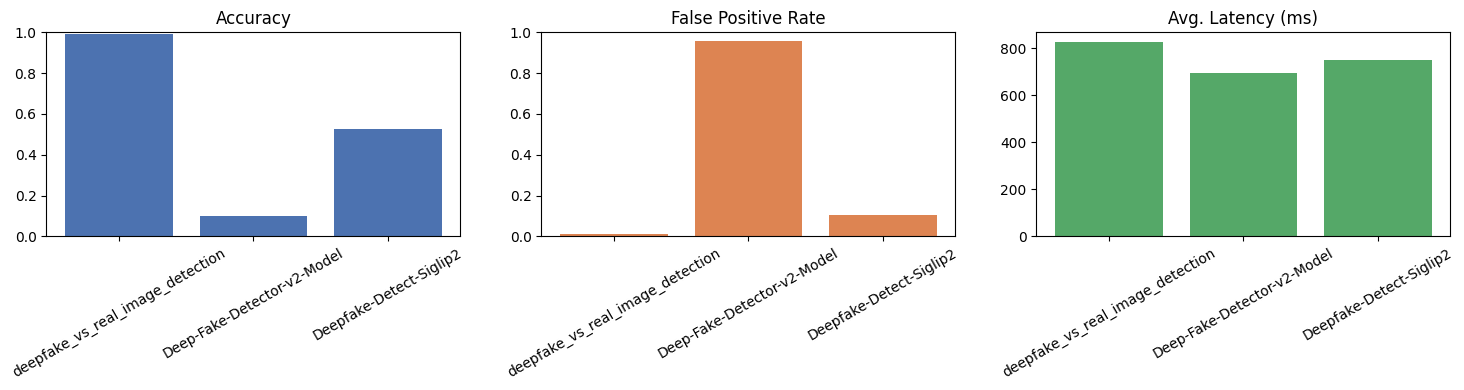

In [27]:
import matplotlib.pyplot as plt

names = [r.model_name.split("/")[-1] for r in results]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(names, [r.accuracy for r in results], color="#4C72B0")
axes[0].set_title("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(names, [r.false_positive_rate for r in results], color="#DD8452")
axes[1].set_title("False Positive Rate")
axes[1].set_ylim(0, 1)

axes[2].bar(names, [r.avg_latency_ms for r in results], color="#55A868")
axes[2].set_title("Avg. Latency (ms)")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("results_chart.png", dpi=150)
plt.show()


## 7. Next step

Copy the printed table (or `results.csv`) into `README.md`'s Results section, and download `results_chart.png` to embed in the repo. This completes the technical half of the research proposal -- the detection benchmark. The proposal's other half (a pre/post-exposure user-trust survey) is a separate, non-coding piece of work described in the proposal itself.

In [28]:
from transformers import pipeline

clf_check = pipeline("image-classification", model="prithivMLmods/Deep-Fake-Detector-v2-Model")

for image, is_fake in samples[:5]:
    result = clf_check(image)
    print(f"true_is_fake={is_fake}  predictions={result}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

true_is_fake=False  predictions=[{'label': 'Deepfake', 'score': 0.8568470478057861}, {'label': 'Realism', 'score': 0.14315292239189148}]
true_is_fake=False  predictions=[{'label': 'Deepfake', 'score': 0.8434221744537354}, {'label': 'Realism', 'score': 0.15657781064510345}]
true_is_fake=True  predictions=[{'label': 'Realism', 'score': 0.91852867603302}, {'label': 'Deepfake', 'score': 0.08147129416465759}]
true_is_fake=True  predictions=[{'label': 'Realism', 'score': 0.8917596340179443}, {'label': 'Deepfake', 'score': 0.10824035853147507}]
true_is_fake=False  predictions=[{'label': 'Deepfake', 'score': 0.864025354385376}, {'label': 'Realism', 'score': 0.13597463071346283}]
